In [44]:
# Check python version
!python --version

Python 3.9.12


In [45]:
# import libraries
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [46]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("green_tripdata_2026-01-experiment")

<Experiment: artifact_location='/workspaces/mlops-zoomcamp-megh/02-experiment-tracking/mlruns/1', creation_time=1780564663873, experiment_id='1', last_update_time=1780564663873, lifecycle_stage='active', name='green_tripdata_2026-01-experiment', tags={}>

In [47]:
# read the data
df = pd.read_parquet("../data/green_tripdata_2026-01.parquet")
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,1.5,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,0.0,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,1.5,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,1.5,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.5,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,None,NaN,25,228,NaN,2.57,17.98,...,0.5,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,None,NaN,223,7,NaN,1.58,14.25,...,0.5,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,None,NaN,256,228,NaN,8.17,3.00,...,0.5,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,None,NaN,66,186,NaN,6.27,30.89,...,0.5,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75


In [48]:
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)

In [49]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

#df.duration = df.duration.dt.total_seconds() / 60

df.duration = df.duration.apply(lambda x: x.total_seconds() / 60)

In [50]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75,27.300000
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00,48.383333
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00,21.300000
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00,16.200000
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00,18.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,None,NaN,25,228,NaN,2.57,17.98,...,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00,15.000000
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,None,NaN,223,7,NaN,1.58,14.25,...,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00,10.000000
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,None,NaN,256,228,NaN,8.17,3.00,...,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00,25.983333
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,None,NaN,66,186,NaN,6.27,30.89,...,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75,25.000000


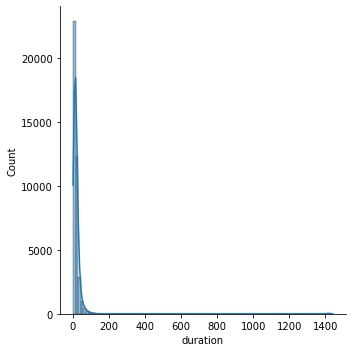

In [51]:
sns.displot(df.duration, bins=100, kde=True)

In [52]:
df.duration.describe(percentiles=[0.95, 0.98, 0.99])

count    40272.000000
mean        20.075434
std         69.852105
min          0.000000
50%         12.883333
95%         44.016667
98%         64.286000
99%         82.886500
max       1439.800000
Name: duration, dtype: float64

In [53]:
df = df[(df.duration >= 1) & (df.duration <= 60)]
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75,27.300000
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00,48.383333
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00,21.300000
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00,16.200000
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00,18.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,None,NaN,25,228,NaN,2.57,17.98,...,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00,15.000000
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,None,NaN,223,7,NaN,1.58,14.25,...,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00,10.000000
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,None,NaN,256,228,NaN,8.17,3.00,...,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00,25.983333
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,None,NaN,66,186,NaN,6.27,30.89,...,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75,25.000000


In [54]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance', 'total_amount']
target = 'duration'

In [55]:
df[categorical] = df[categorical].astype('str')

/tmp/ipykernel_27344/790595652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical] = df[categorical].astype('str')


In [56]:
df.dtypes

VendorID                          int32
lpep_pickup_datetime     datetime64[ns]
lpep_dropoff_datetime    datetime64[ns]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                     object
DOLocationID                     object
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
cbd_congestion_fee              float64
duration                        float64
dtype: object

In [57]:
train_dict = df[categorical + numerical].to_dict(orient='records')

In [58]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dict)
X_train

<38088x473 sparse matrix of type '<class 'numpy.float64'>'
	with 152352 stored elements in Compressed Sparse Row format>

In [59]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=11',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=119',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',
 'DOLocationID=146',
 'DOLocationID=147',
 'DOLocationID=148',
 'DOLocationID=149'

In [60]:
y_train = df[target].values
y_train.shape

(38088,)

In [61]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

LinearRegression()

In [62]:
y_pred = linear_regression.predict(X_train)

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


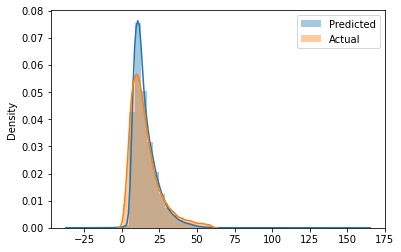

In [63]:
sns.distplot(y_pred, label='Predicted')
sns.distplot(y_train, label='Actual')
plt.legend()

In [64]:
# This shows that our model is wrong on average by 6.5 minutes, which is not good.

mean_squared_error(y_train, y_pred, squared=False)

6.122279867301761

#### Creating everything from above into one single modular code to consider validation code too

In [65]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)

    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

    df.duration = df.duration.apply(lambda x: x.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']

    df[categorical] = df[categorical].astype(str)

    return df

In [66]:
df_train = read_dataframe("../data/green_tripdata_2026-01.parquet")
df_val = read_dataframe("../data/green_tripdata_2026-02.parquet")

len(df_train), len(df_val)

(38088, 35319)

In [67]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


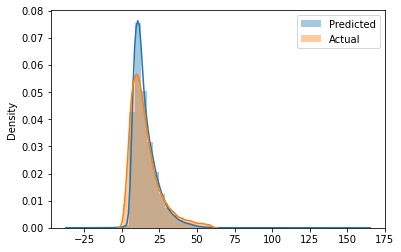

In [68]:
categorical = ['PU_DO']
numerical = ['duration']

dv = DictVectorizer()

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)


sns.distplot(y_pred, label='Predicted')
sns.distplot(y_train, label='Actual')
plt.legend()
    

In [69]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [70]:
with mlflow.start_run():
    mlflow.set_tag("Developer Name", "Megh Modi")
    mlflow.log_param("model_type", "Linear Regression")

    mlflow.log_param("train_data_path", "../data/green_tripdata_2026-01.parquet")
    mlflow.log_param("val_data_path", "../data/green_tripdata_2026-02.parquet")
    
    # alpha = 0.1
    # mlflow.log_param("alpha", alpha)
    
    linear_regression = LinearRegression()
    linear_regression.fit(X_train, y_train)

    y_pred = linear_regression.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)
    
    with open('models/linear_regression.bin', 'wb') as f_out:
        pickle.dump((dv, linear_regression), f_out)
    
    mlflow.log_artifact(local_path="models/linear_regression.bin", artifact_path="models")

rmse

4.724127675753466e-07

In [71]:
with mlflow.start_run():
    
    mlflow.set_tag("Developer Name", "Megh Modi")
    mlflow.log_param("model_type", "Lasso Regression")

    mlflow.log_param("train_data_path", "../data/green_tripdata_2026-01.parquet")
    mlflow.log_param("val_data_path", "../data/green_tripdata_2026-02.parquet")
    
    alpha = 1.0
    mlflow.log_param("alpha", alpha)
    
    lasso_regression = Lasso(alpha=alpha)
    lasso_regression.fit(X_train, y_train)

    y_pred = lasso_regression.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)
    
    with open('models/lasso_regression.bin', 'wb') as f_out:
        pickle.dump((dv, lasso_regression), f_out)
    
    mlflow.log_artifact(local_path="models/lasso_regression.bin", artifact_path="models")

rmse

0.09758636919053224

In [72]:


with mlflow.start_run():
    mlflow.set_tag("Developer Name", "Megh Modi")
    mlflow.log_param("model_type", "Ridge Regression")

    mlflow.log_param("train_data_path", "../data/green_tripdata_2026-01.parquet")
    mlflow.log_param("val_data_path", "../data/green_tripdata_2026-02.parquet")

    alpha = 1.0
    mlflow.log_param("alpha", alpha)

    ridge_regression = Ridge(alpha=alpha)
    ridge_regression.fit(X_train, y_train)

    y_pred = ridge_regression.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)
    
        
    with open('models/ridge_regression.bin', 'wb') as f_out:
        pickle.dump((dv, ridge_regression), f_out)
        
    mlflow.log_artifact(local_path="models/ridge_regression.bin", artifact_path="models")    
rmse

0.0005082761037723021

#### Using XGBoost - Video 3 - Module 2

In [73]:
import xgboost as xgb
import gc

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [74]:
# def objective(params):
#     with mlflow.start_run(nested=True):
#         mlflow.set_tag("Developer Name", "Megh Modi")
#         mlflow.log_param("model_type", "XGBoost Regression")

#         mlflow.log_param("train_data_path", "../data/green_tripdata_2026-01.parquet")
#         mlflow.log_param("val_data_path", "../data/green_tripdata_2026-02.parquet")

#         mlflow.log_params(params)

#         booster = xgb.train(
#             params=params,
#             dtrain=xgb.DMatrix(X_train, label=y_train),
#             num_boost_round=100,
#             evals=[(xgb.DMatrix(X_val, label=y_val), 'validation')],
#             early_stopping_rounds=50
#         )
        
#         y_pred = booster.predict(xgb.DMatrix(X_val, label=y_val))
#         rmse = mean_squared_error(y_val, y_pred, squared=False)
#         mlflow.log_metric("rmse", rmse)
        
#         gc.collect()
        
#     return {'loss': rmse, 'status': STATUS_OK}

In [75]:
# search_space = {
#     'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
#     'learning_rate': hp.loguniform('learning_rate', -3, 0),
#     'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
#     'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
#     'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
#     'objective': 'reg:linear',
#     'seed': 42
# }

In [76]:
# best_result = fmin(
#     fn=objective,
#     space=search_space,
#     algo=tpe.suggest,
#     max_evals=5,
#     trials=Trials()
# )

In [77]:
params = {
    "learning_rate": 0.0784901317383746,
    "max_depth": 84,
    "min_child_weight": 0.49036887395182704,
    "objective": "reg:linear",
    "reg_alpha": 0.014718634417135872,
    "reg_lambda": 0.0038376926340167993,
    "seed": 42
}

## Normal logging

# with mlflow.start_run():
#     mlflow.set_tag("Developer Name", "Megh Modi")
#     mlflow.log_param("model_type", "XGBoost Regression")

#     mlflow.log_param("train_data_path", "../data/green_tripdata_2026-01.parquet")
#     mlflow.log_param("val_data_path", "../data/green_tripdata_2026-02.parquet")

#     mlflow.log_params(params)
    
#     booster = xgb.train(
#         params=params,
#         dtrain=xgb.DMatrix(X_train, label=y_train),
#         num_boost_round=100,
#         evals=[(xgb.DMatrix(X_val, label=y_val), 'validation')],
#         early_stopping_rounds=50
#     )

In [ ]:
## Auto Logging

mlflow.xgboost.autolog()

from mlflow.models.signature import infer_signature

with mlflow.start_run():
    mlflow.log_param("model_type", "XGBoost Regression")

    booster = xgb.train(
        params=params,
        dtrain=xgb.DMatrix(X_train, label=y_train),
        num_boost_round=100,
        evals=[(xgb.DMatrix(X_val, label=y_val), 'validation')],
        early_stopping_rounds=50
    )
    
    with open('models/preprocessor.b', 'wb') as f_out:
        pickle.dump(dv, f_out)
        
    mlflow.log_artifact(local_path="models/preprocessor.b", artifact_path="preprocessor")

    # Create an input example and signature so MLflow records the model signature
    # X_val may be a sparse matrix; convert a small slice to array for the example
    input_example = X_val[:5].toarray() if hasattr(X_val[:5], "toarray") else X_val[:5]
    signature = infer_signature(input_example, y_val[:5])

    mlflow.xgboost.log_model(booster, artifact_path="models", signature=signature, input_example=input_example)


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:38:33] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation-rmse:9.56001
[1]	validation-rmse:8.81038
[2]	validation-rmse:8.11959
[3]	validation-rmse:7.48305
[4]	validation-rmse:6.89647
[5]	validation-rmse:6.35596
[6]	validation-rmse:5.85785
[7]	validation-rmse:5.39868
[8]	validation-rmse:4.97579
[9]	validation-rmse:4.58578
[10]	validation-rmse:4.22664
[11]	validation-rmse:3.89510
[12]	validation-rmse:3.59020
[13]	validation-rmse:3.30869
[14]	validation-rmse:3.04978
[15]	validation-rmse:2.81090
[16]	validation-rmse:2.59102
[17]	validation-rmse:2.38839
[18]	validation-rmse:2.20061
[19]	validation-rmse:2.02967
[20]	validation-rmse:1.87024
[21]	validation-rmse:1.72522
[22]	validation-rmse:1.58943
[23]	validation-rmse:1.46620
[24]	validation-rmse:1.35183
[25]	validation-rmse:1.24710
[26]	validation-rmse:1.14893
[27]	validation-rmse:1.05968
[28]	validation-rmse:0.97865
[29]	validation-rmse:0.90251
[30]	validation-rmse:0.83298
[31]	validation-rmse:0.76896
[32]	validation-rmse:0.71032
[33]	validation-rmse:0.65622
[34]	validation-rmse:0.6

2026/06/06 17:40:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 17:40:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:40:53] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/06/06 17:41:02 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpfwcdd5xs/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/06/06 17:41:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:41:29] WARNING: /workspace/src/c_api/c_api.cc:

### Model Management and Saving the model

##### 1. Saving models as artifacts (Shown above in regressions in section 1)

#### 2. Saving models using mlflow.<model_type>.log_model()

In [79]:
from mlflow.models.signature import infer_signature

with mlflow.start_run():
    
    mlflow.set_tag("Developer Name", "Megh Modi")
    mlflow.log_param("model_type", "XGBoost Regression")
    
    params = {
        "learning_rate": 0.0784901317383746,
        "max_depth": 84,
        "min_child_weight": 0.49036887395182704,
        "objective": "reg:linear",
        "reg_alpha": 0.014718634417135872,
        "reg_lambda": 0.0038376926340167993,
        "seed": 42
    }
    
    mlflow.log_params(params)
    
    booster = xgb.train(
        params=params,
        dtrain=xgb.DMatrix(X_train, label=y_train),
        num_boost_round=100,
        evals=[(xgb.DMatrix(X_val, label=y_val), 'validation')],
        early_stopping_rounds=50
    )
    
    y_pred = booster.predict(xgb.DMatrix(X_val, label=y_val))
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)
    
    with open('models/preprocessor.b', 'wb') as f_out:
        pickle.dump(dv, f_out)
    
    mlflow.log_artifact(local_path="models/preprocessor.b", artifact_path="preprocessor")

    # Create an input example and signature so MLflow records the model signature
    input_example = X_val[:5].toarray() if hasattr(X_val[:5], "toarray") else X_val[:5]
    signature = infer_signature(input_example, y_val[:5])

    mlflow.xgboost.log_model(booster, artifact_path="models", signature=signature, input_example=input_example)

[0]	validation-rmse:9.56001


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:41:38] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[1]	validation-rmse:8.81038
[2]	validation-rmse:8.11959
[3]	validation-rmse:7.48305
[4]	validation-rmse:6.89647
[5]	validation-rmse:6.35596
[6]	validation-rmse:5.85785
[7]	validation-rmse:5.39868
[8]	validation-rmse:4.97579
[9]	validation-rmse:4.58578
[10]	validation-rmse:4.22664
[11]	validation-rmse:3.89510
[12]	validation-rmse:3.59020
[13]	validation-rmse:3.30869
[14]	validation-rmse:3.04978
[15]	validation-rmse:2.81090
[16]	validation-rmse:2.59102
[17]	validation-rmse:2.38839
[18]	validation-rmse:2.20061
[19]	validation-rmse:2.02967
[20]	validation-rmse:1.87024
[21]	validation-rmse:1.72522
[22]	validation-rmse:1.58943
[23]	validation-rmse:1.46620
[24]	validation-rmse:1.35183
[25]	validation-rmse:1.24710
[26]	validation-rmse:1.14893
[27]	validation-rmse:1.05968
[28]	validation-rmse:0.97865
[29]	validation-rmse:0.90251
[30]	validation-rmse:0.83298
[31]	validation-rmse:0.76896
[32]	validation-rmse:0.71032
[33]	validation-rmse:0.65622
[34]	validation-rmse:0.60673
[35]	validation-rmse:0.

2026/06/06 17:43:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 17:43:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:43:50] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/06/06 17:43:59 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpbvfuf32u/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/06/06 17:44:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:44:32] WARNING: /workspace/src/c_api/c_api.cc: